In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [6]:
import sklearn
from sklearn.decomposition import PCA

In [7]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [8]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [9]:
pulse_header = "D:/K_sunada/result/control_pulses/"
fogi = "/2024-06-01/2024-06-01T190833_e791f89d-Control_Pulse"
fogi_tr = "/2024-06-01/2024-06-01T204847_e7bb0e65-Control_Pulse"
fogi_anti = "/2024-05-31/2024-05-31T105648_0a8ccd46-Control_Pulse"
fogi_anti_tr = "/2024-05-31/2024-05-31T110825_a9eb6157-Control_Pulse"

In [10]:
dd = datadict_from_hdf5(pulse_header+fogi+"/data")
dd_tr = datadict_from_hdf5(pulse_header+fogi_tr+"/data")
dd_anti = datadict_from_hdf5(pulse_header+fogi_anti+"/data")
dd_anti_tr = datadict_from_hdf5(pulse_header+fogi_anti_tr+"/data")
time = dd['time']['values']
fogi = dd['control_pulse']['values']
fogi_tr = dd_tr['control_pulse']['values']
fogi_anti = dd_anti['control_pulse']['values']
fogi_anti_tr = dd_anti_tr['control_pulse']['values']

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 800x300 with 0 Axes>

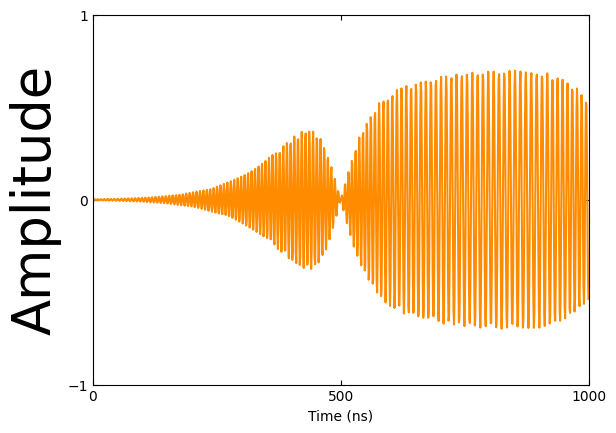

In [11]:
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'Amplitude',fontsize=38)
ax0.plot(time,  fogi_anti, '-',color='darkorange')# - np.mean(y_base))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-1, 1)
ax0.set_xlim(0, 1000)
# plt.legend()
plt.xticks(np.arange(0, 1001, 500))
plt.yticks(np.arange(-1, 1.1, 1))
# plt.savefig('fogi.png', bbox_inches='tight')
plt.show()

<Figure size 800x300 with 0 Axes>

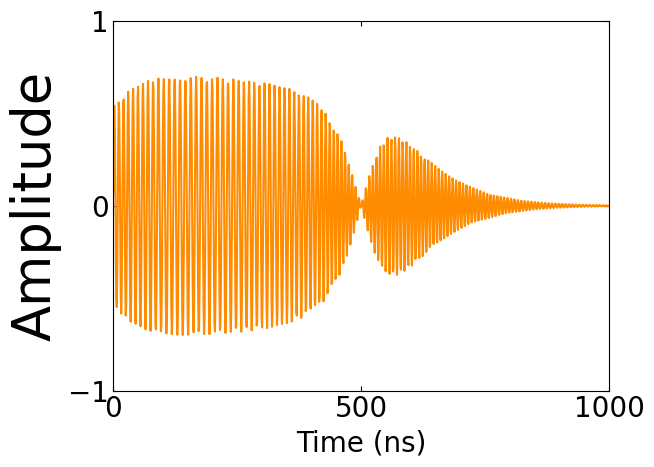

In [12]:
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'Amplitude',fontsize=38)
ax0.plot(time,  fogi_anti_tr, '-',color='darkorange')# - np.mean(y_base))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-1, 1)
ax0.set_xlim(0, 1000)
# plt.legend()
plt.xticks(np.arange(0, 1001, 500))
plt.yticks(np.arange(-1, 1.1, 1))
# plt.savefig('fogi_tr.png', bbox_inches='tight')
plt.show()

## 7/26 photon absorption

In [13]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [14]:
header = "D:/K_sunada/result/CDY163/"

In [15]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_ref']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

photon freq = 10.3875

In [52]:
ph0_fo0 = "/2024-07-24/2024-07-24T225618_80645e4c-75-sym_JPA_ab_fogi_timing"
ph1_fo1 = "/2024-07-25/2024-07-25T091209_886e612b-75-sym_JPA_ab_fogi_timing"
ph1_fo0 = "/2024-07-26/2024-07-26T152306_8582d5d0-75-sym_JPA_ab_fogi_timing"
ph0_fo1 = "/2024-07-26/2024-07-26T111605_03328c64-75-sym_JPA_ab_fogi_timing"

[ -0.84509419  -6.56846656  -9.62751501  -3.69074012  -6.27292239
 -16.09214035  -4.683834   -13.29537779   1.12505311  -9.9604062
  -6.08087163  -6.87594655  -4.65775139   0.94159689  -2.56264631
   2.92853673  -7.79711918  -0.58191811  -3.09489643  -0.90680325
  10.50670029   4.06555354  -5.62611929   4.512063     0.48851111
   7.73815833   9.84693037  10.5313707   -1.42241949   3.89605984
  20.9322355    7.70766961  14.11574794  18.22973271  12.98477061
  21.24608477  19.58098138  24.98980379  25.93575399  10.08876049
  20.48903037  16.76497647  23.14913245   4.89265378  20.37689028
  23.66366635  23.14424243  23.43509687  26.27855584  17.42197527
  28.86182975  27.28878503  29.82771207  28.5153793   31.55689878
  29.27602103  36.26276279  26.71796296  31.29561976  33.76532938
  33.93615078  39.42721998  42.05563199  40.39969431  37.12366519
  43.2618213   40.14713106  34.04511217  39.92105268  36.05816744
  44.01946436  34.75426156  33.39277087  30.5337043   33.88828713
  36.441960

<Figure size 800x600 with 0 Axes>

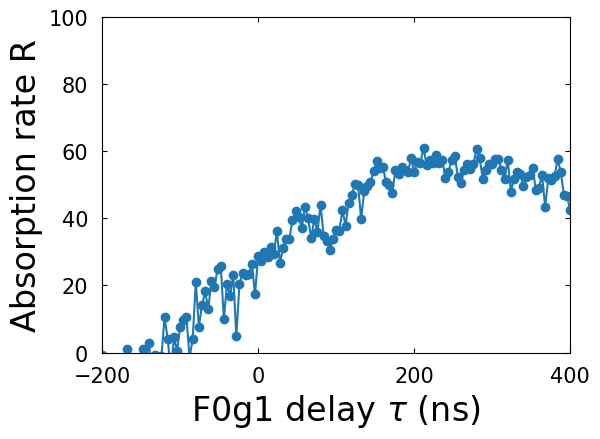

In [47]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 151
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (10.5-10.3875)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()
time00 = d[0][ph_amp]
ph0fo0 = d[5][ph_amp]

[-2.87013090e+00 -5.31789220e+00 -1.02622956e-01 -5.66503130e+00
 -1.17076104e+01 -1.21672322e+01 -2.79931521e+00 -4.70646201e+00
 -5.75518353e+00 -3.52334631e+00 -5.32777212e+00 -4.22926997e+00
 -6.52206113e+00 -8.93156117e+00 -8.01571659e+00  1.00994329e+01
  7.06341257e+00  1.16935818e+01  8.78524422e+00  3.51290572e+00
  6.81006311e+00 -3.26954510e-01 -1.51840488e+00  3.34117008e+00
  3.77299552e+00  8.96937028e-01 -7.72026880e-02  2.32556362e+00
  2.64655833e+00  9.65318705e+00  5.62417838e+00  1.06921743e-01
  6.05260797e+00 -2.92688120e+00 -3.31230158e-02  5.36630527e+00
  9.46557546e+00  2.45360039e+00  5.75392557e+00 -4.54614126e+00
 -1.15621978e+00  5.63473530e+00  5.78204907e+00  1.36759535e+01
  1.32141470e+01  2.03956493e+00  1.45164240e+01  1.49938211e+01
  1.72371151e+01  1.57949138e+01  1.50887678e+01  7.05271884e+00
  1.75585383e+01  2.32948268e+01  2.12088429e+01  1.92256779e+01
  2.04655464e+01  2.01803371e+01  2.07740488e+01  2.30721339e+01
  2.15702765e+01  2.04457

<Figure size 800x600 with 0 Axes>

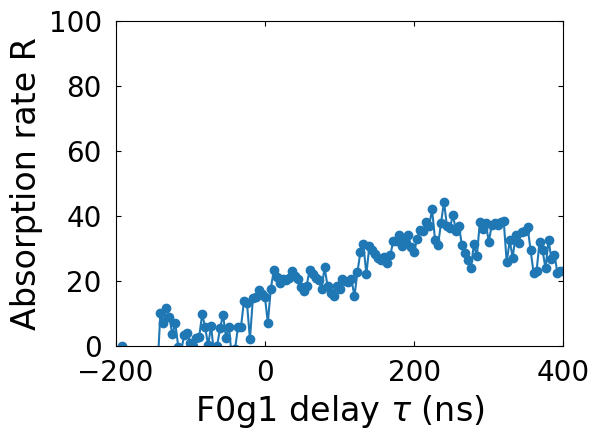

In [48]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 151
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (10.5-10.3875)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()
time11 = d[0][ph_amp]
ph1fo1 = d[5][ph_amp]

[26.69577906 38.5752795  36.13884257 34.14692962 41.82000605 35.2497989
 41.61011861 35.07351959 32.69783628 32.34489527 35.59307373 38.75930812
 34.10144652 37.8055774  34.75116591 35.66633749 40.09929011 36.49379422
 35.29925063 35.33918937]


<Figure size 800x600 with 0 Axes>

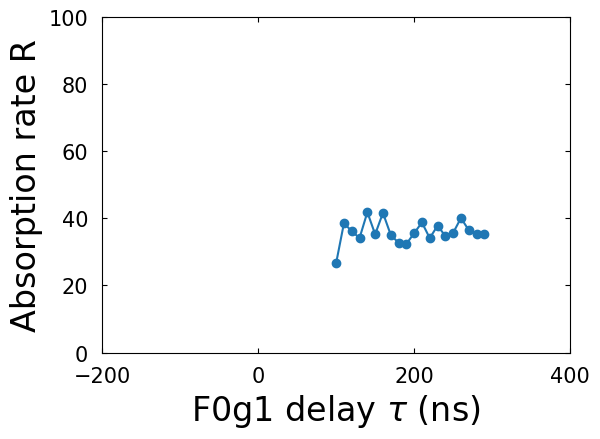

In [53]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (10.5-10.3875)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()
time10 = d[0][ph_amp]
ph1fo0 = d[5][ph_amp]

[18.4204938  16.44042288  8.04862142 22.36238858 10.6156033  13.79974494
 25.61672747 22.4994727  20.88317696 31.3794371  28.0367058  36.60966357
 65.4341644  38.36241223 41.26501887 43.5466347  49.74742062 45.09494048
 49.7386322  49.54328564 42.33605152 48.91713072 43.38038345 25.74931465
 50.03285975 54.48581126 57.0853863  58.24699704 57.61002459 55.73974026
 52.58977364 51.85793923 56.17062414 50.39672659 50.01107433 44.97936188
 47.12999376 40.33514344 45.33824985 44.34612871 40.83324052]


<Figure size 800x600 with 0 Axes>

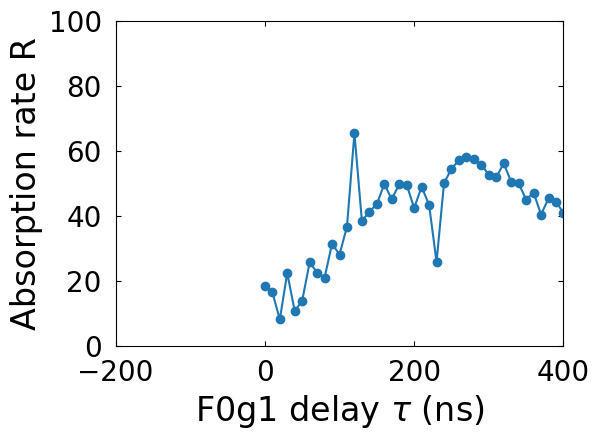

In [54]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (10.5-10.3875)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()
time01 = d[0][ph_amp]
ph0fo1 = d[5][ph_amp]

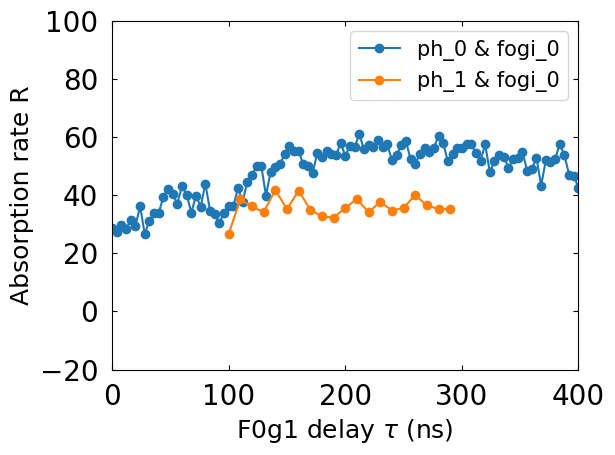

In [55]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-20, 100)
ax1.set_xlim(0, 400)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o-", label= "ph_0 & fogi_0")
# plt.plot(time11, ph1fo1, "o-", label= "ph_1 & fogi_1")
plt.plot(time10, ph1fo0, "o-", label= "ph_1 & fogi_0")
# plt.plot(time01, ph0fo1, "o-", label= "ph_0 & fogi_1")
plt.legend()
plt.show()

fogi freq = 10.3825

In [22]:
fogi_timing = "/2024-07-26/2024-07-26T092949_2b1e1924-75-sym_JPA_ab_fogi_timing"

[  3.02603311  14.30641689  11.91490519  30.62662006  39.63749961
  26.47221197  38.91716148  29.25362874  42.04420189  50.22564993
  21.86277975   2.36947303   8.96073473   9.20004056  41.89181656
  36.85993351  23.9359206   -4.92791425 -13.79159593  10.79343548
 -24.38860059 -16.5823089  -11.32225747 -17.09466562 -39.87248788
   2.65952497  -9.42580234  -2.68151841 -24.99369657]


<Figure size 800x600 with 0 Axes>

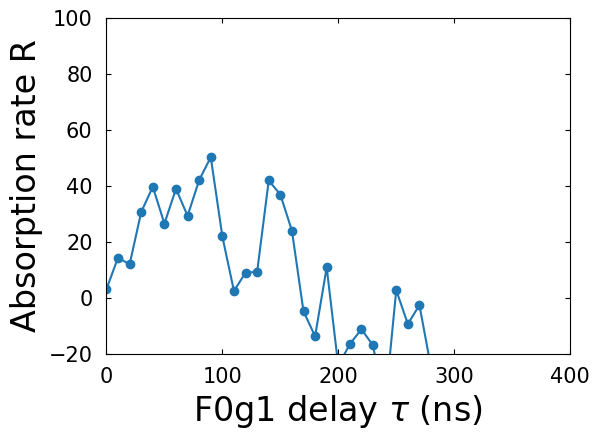

In [23]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_timing = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (10.5-10.3825)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(-20, 100)
ax1.set_xlim(0, 400)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

In [24]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing1
num_of_ph_amp = 1
num_of_fogi_timing = 11
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 100)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

NameError: name 'fogi_timing1' is not defined

[67.39379601 71.92052816 80.19427694 82.17221805 85.39692591 87.15062706
 91.0632048  92.14926779 92.66792449 90.8139672  90.57310853]


<Figure size 800x600 with 0 Axes>

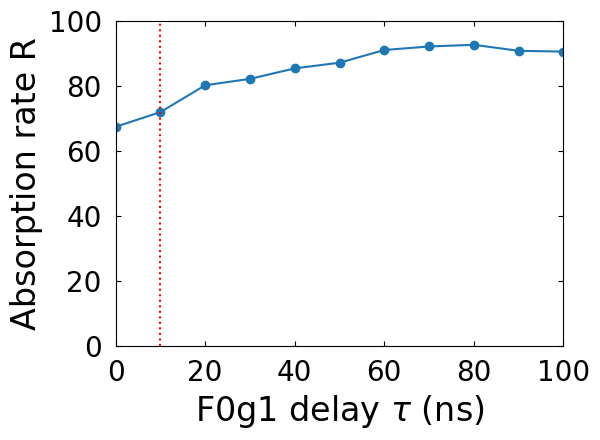

In [ ]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing2
num_of_ph_amp = 1
num_of_fogi_timing = 11
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 100)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

93.0


<Figure size 800x300 with 0 Axes>

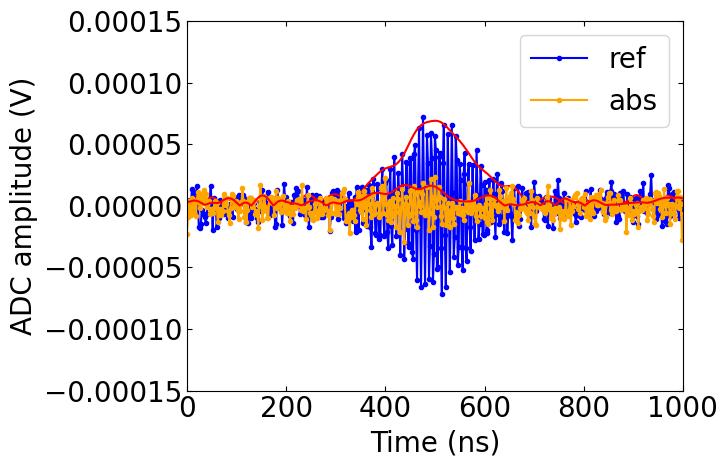

In [ ]:
## waveform
ph_amp = 0
fogi_freq = 16
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_freq = 46
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit as lmf
from lmfit.models import (
    LorentzianModel, GaussianModel, SineModel, LinearModel, ConstantModel
)
import scipy.signal as sg
from scipy.special import erfc
from scipy import interpolate
from sklearn.decomposition import PCA
from datataking import search_datadict_miyamura
from scipy.integrate import quad
from scipy.special import spence


class Analysis:
    def __init__(self, data:np.ndarray, v1:np.ndarray, v2:np.ndarray|None=None) -> None:
        self.v1 = np.unique(v1)
        if v2 is not None:
            self.v2 = np.unique(v2)
            self.data = data.reshape(len(self.v2), len(self.v1))
        else:
            self.data = data
            self.v2 = None

    def pca(self):
        data_IQ = np.array([self.data.real, self.data.imag]).T
        pca = PCA(n_components=2)
        pca.fit(data_IQ)
        data_pca = pca.transform(data_IQ)
        return data_pca[: ,0].real
    
    def pca_2d(self):
        assert self.v2 is not None
        data = self.data.ravel()
        data_IQ = np.array([data.real, data.imag]).T
        pca = PCA(n_components=2)
        pca.fit(data_IQ)
        data_pca = pca.transform(data_IQ)
        return data_pca[: ,0].real.reshape(len(self.v2), len(self.v1))
    
    def plot_adjust(self, title=None, labels=None, lims=None):
        if title is not None:
            plt.title(title)
        if labels is not None:
            plt.xlabel(labels[0])
            plt.ylabel(labels[1])
        if lims is not None:
            plt.xlim(lims[0])
            if len(lims) == 2:
                plt.ylim(lims[1])
    
    def plot(self, title=None, labels=None, lims=None, figsize=(4, 3), legend=False, grid=False, N=1, show=True):
        """
        title:str \n
        labels = [xlabel, ylabel] \n
        lims = [(),()]
        """
        fig = plt.figure(figsize=figsize)
        if self.v2 is None:
            data = self.pca()
            plt.plot(self.v1, data * N)
        else:
            if self.data.dtype == "complex128":
                data = self.pca_2d()
                assert data.dtype != "complex128", data.dtype
            else: data = self.data

            c = plt.pcolormesh(self.v1, self.v2, data * N, shading="auto")
            cbar = fig.colorbar(c)
            cbar.ax.tick_params(labelsize=14)
        self.plot_adjust(title=title, labels=labels, lims=lims)
        plt.grid(grid)
        if legend: plt.legend()
        if show:plt.show()

    def fit_1d(self, kind, plot=False):
        if kind == "resonator":
            F = ResonatorFit(self.data, self.v1)
            return F.fit()
        data_pca = self.pca()
        F = Fit(data_pca, self.v1)
        if kind == "ramsey": res = F.ramsey_fit()
        elif kind == "rabi": res = F.rabi_fit()
        elif kind == "gaussian": res = F.gaussian_fit()
        elif kind == "decay": res = F.decay_fit()
        # if plot:
        #     plt.plot(self.v1, data_pca)
        #     plt.plot(self.v1, res.best_fit)
        #     plt.plot(self.v1, res.init_fit)
        return res
    # def fit_1d(self):

    def fit_successive(self, kind, extract_parameter=None):
        assert self.v2 is not None
        results = []
        for i, v in enumerate(self.v1):
            data = self.data[i]
            results.append(self.fit_1d(kind=kind))
        return results

class Fit:
    def __init__(self, data, v,) -> None:
        assert len(data) == len(v), f"{len(data)} != {len(v)}"
        self.data = data 
        self.v = v
        self.envelope = np.abs(sg.hilbert(data))
        # plt.figure(figsize=(4,2));plt.plot(self.v, self.data)
        # plt.show()
    
    def find_osc_init(self):
        x_fft, y_fft = fourier_tr(self.v, self.data)
        x_fft, y_fft = start_stop(x_fft, y_fft, 0, x_fft[-1])
        A = max(self.data) - min(self.data)
        off = np.mean(self.data)
        freq = abs(x_fft[np.argmax(np.abs(y_fft))])
        return A, off, freq, np.angle(y_fft[np.argmax(np.abs(y_fft))])
    
    def find_decay_init(self, hilbert=False):
        if hilbert: data = self.envelope
        else: data = self.data
        off_ini = np.mean(data[-5:])
        moving_average = np.convolve(data, np.ones(25) / 25, mode="valid")
        A_ini = moving_average[0]
        gamma_ini = abs((moving_average[0] - moving_average[5]) / (self.v[0] - self.v[5])) / A_ini
        return A_ini, gamma_ini, off_ini

    def find_decay_init2(self, hilbert=False):
        if hilbert: data = self.envelope
        else: data = self.data
        off_ini = np.mean(data[-5:])
        moving_average = np.convolve(data, np.ones(25) / 25, mode="valid")
        A_ini = self.data[0]-off_ini
        gamma_ini = abs((moving_average[0] - moving_average[5]) / (self.v[0] - self.v[5])) / A_ini
        return A_ini, gamma_ini, off_ini

    def quadra_fit(self):
        def modelf(x, a, b, c): return a*x**2 + b*x + c
        par_ini = dict(a=-0.5, b=0, c=5.65)
        par_max = dict(a=np.inf, b=np.inf, c=np.inf)
        par_min = dict(a=-np.inf, b=-np.inf, c=-np.inf)
        par_var = dict(a=True, b=False, c=True)
        model = lmf.Model(modelf)
        params = model.make_params()
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        return model.fit(self.data, x=self.v, params=params, method='leastsq')

    def ramsey_fit(self):
        def modelf(t, T2, freq, A, phi, off):
            return A * np.exp(-t / T2) * np.cos(2 * np.pi * freq * t + phi) + off
        A, off, freq, phi = self.find_osc_init()
        T2_ini = 1 / self.find_decay_init(hilbert=True)[1]
        par_ini = dict(T2=T2_ini, freq=freq, A=A/2, phi=phi, off=off)
        par_max = dict(T2=10 * T2_ini, freq=freq * 2, A=A*2, phi=np.inf, off=np.inf)
        par_min = dict(T2=0, freq=0, A=A / 1e5, phi=-np.inf, off=-np.inf)
        par_var = dict(T2=True, freq=True, A=True, phi=True, off=True)
        model = lmf.Model(modelf)
        params = model.make_params()
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        return model.fit(self.data, t=self.v, params=params, method='leastsq')
    
    def decay_fit(self, hilbert=False):
        def modelf(t, T1, A, off): return A * np.exp(-(t-t[0]) / T1) + off
        A, gamma, off = self.find_decay_init2(hilbert=hilbert)
        gamma *= 2
        par_ini = dict(T1=1/abs(gamma), A=A, off=off)
        par_max = dict(T1=10 / abs(gamma), A=A*2, off=abs(off) * 5)
        par_min = dict(T1=0, A=A / 1e5, off=-abs(off) * 5)
        par_var = dict(T1=True, A=True, phi=True, off=True)
        model = lmf.Model(modelf)
        params = model.make_params()
        # print(par_ini["off"])
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        return model.fit(self.data, t=self.v, params=params, method='leastsq')
    
    def sin_fit(self):
        def modelf(t, freq, A, phi, off): 
            return A * np.cos(2 * np.pi * freq * t + phi) + off
        A, off, freq, phi = self.find_osc_init()
        par_ini = dict(freq=freq, A=A, phi=phi, off=off)
        par_max = dict(freq=freq * 2, A=A*2, phi=np.pi, off=abs(off) * 5)
        par_min = dict(freq=0, A=A / 1e5, phi=-np.pi, off=-abs(off) * 5)
        par_var = dict(freq=True, A=True, phi=True, off=True)
        model = lmf.Model(modelf)
        params = model.make_params()
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        return model.fit(self.data, t=self.v, params=params, method='leastsq')

    def linear_fit(self):
        model = LinearModel()
        par = model.guess(self.data, x=self.v)
        return model.fit(self.data, par, x=self.v)

    def rabi_fit(self):
        model = SineModel()
        par = model.guess(self.data, x=self.v)
        res = model.fit(self.data, par, x=self.v)
        omega = res.params.valuesdict()["frequency"]
        phi = res.params.valuesdict()["shift"]
        delta = np.pi / omega
        n_list = np.arange(self.v[0] // delta, self.v[-1] // delta + 6, 1)
        print([((n-0.5)*np.pi-phi)/omega for n in n_list if (n*np.pi-phi)/omega >= self.v[0] and (n*np.pi-phi)/omega<self.v[-1]])
        return res

    def lorentz_fit(self):
        model = LorentzianModel() + ConstantModel()
        par = LorentzianModel().guess(self.data, x=self.v)
        par += ConstantModel().make_params()
        return model.fit(self.data, par, x=self.v)
    
    def gaussian_fit(self):
        model = GaussianModel()
        par = model.guess(self.data, x=self.v)
        return model.fit(self.data, par, x=self.v)

class ResonatorFit:
    def __init__(self, data, f) -> None:
        assert len(data) == len(f), f"{len(data)} != {len(f)}"
        self.data = data 
        self.f = f
        self.B = np.array([[0,0,0,-2], [0,1,0,0], [0,0,1,0], [-2,0,0,0]])

    def plot(self, with_fit=False, init=False):
        res = self.fit()
        fig = plt.figure(figsize=(8, 4))
        ax = fig.add_subplot(1, 2, 1)
        ax.plot(self.data.real, self.data.imag, "ko")
        ax.set_xlabel("Real")
        ax.set_ylabel("Imag")
        ax2 = fig.add_subplot(1, 2, 2)
        ax2.plot(self.f, np.unwrap(np.angle(self.data)), "ko")
        ax2.set_xlabel("Frequency (GHz)")
        ax2.set_ylabel("Phase (rad)")
        if with_fit:
            s11 = res.best_fit
            ax.plot(s11.real, s11.imag, "r--")
            ax2.plot(self.f, np.unwrap(np.angle(s11)))
            if init:
                ax.plot(res.init_fit.real, res.init_fit.imag, "g--")
                ax2.plot(self.f, np.unwrap(np.angle(res.init_fit)))
        plt.show()

    def return_M(self):
        x, y = self.data.real, self.data.imag
        z = x**2 + y**2
        M_11, M_12, M_13, M_14 = np.sum(z**2), np.sum(x*z), np.sum(y*z), np.sum(z)
        M_22, M_23, M_24 = np.sum(x**2), np.sum(x*y), np.sum(x)
        M_33, M_34 = np.sum(y**2), np.sum(y)
        M_44 = len(x)
        M = np.array(
            [[M_11,M_12,M_13,M_14],
            [M_12,M_22,M_23,M_24],
            [M_13,M_23,M_33,M_34],
            [M_14,M_24,M_34,M_44]]
        )
        return M
    
    def center_of_circle(self):
        def determinant(eta, M): return np.linalg.det(M - eta * self.B)
        from scipy.optimize import newton
        M = self.return_M()
        B_inv = np.linalg.inv(self.B)
        try: eta = newton(determinant, 0, args=(M,), tol=1e-13)
        except: eta=0.1
        X = np.linalg.inv(np.dot(B_inv,M)-eta*np.eye(4)-1e-5*np.eye(4))
        a = np.array([1,0,0,0])
        for _ in range(1000):
            a = np.dot(X,a)
            a = a / np.sqrt((a[1]**2 + a[2]**2 -4*a[0]*a[3]))
        x_c = -a[1] / 2 / a[0]
        y_c = -a[2] / 2 / a[0]
        r_0 = 1 / 2 / np.abs(a[0])
        return x_c, y_c, r_0
    
    def guess_phase(self, phase):
        deriv = np.diff(phase)
        F = Fit(deriv, self.f[1:])
        lor_fit = F.lorentz_fit()
        f_r_ini = lor_fit.params.valuesdict()["center"]
        kappa = lor_fit.params.valuesdict()["sigma"]
        return f_r_ini, f_r_ini / kappa
    
    def phase_fit(self, phase):
        def modelf(x, f_r, theta_0, Q_l, C):
            return theta_0 + 2 * np.arctan(2 * Q_l * (1 - (x / f_r))) - C * (x - f_r) * 2 * np.pi
        model = lmf.Model(modelf)
        f_r_ini, Q_l_ini = self.guess_phase(phase)
        par_ini = dict(f_r=f_r_ini, theta_0=phase[0]-np.pi, Q_l=Q_l_ini, C=0,)
        par_max = dict(f_r=f_r_ini*2, theta_0=np.inf, Q_l=np.inf, C=np.inf,)
        par_min = dict(f_r=f_r_ini/2, theta_0=-np.inf, Q_l=0, C=-np.inf,)
        par_var = dict(f_r=True, theta_0=True, Q_l=True, C=True,)
        model = lmf.Model(modelf)
        params = model.make_params()
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        res = model.fit(phase, params, x=self.f)
        # fig = plt.figure()
        # plt.plot(self.f, phase)
        # plt.plot(self.f, res.best_fit)
        # plt.plot(self.f, res.init_fit)
        # plt.show()
        return res
    
    def guess(self):
        x_c, y_c, A = self.center_of_circle()
        r_0 = np.sqrt(x_c**2 + y_c**2)
        # assert A > r_0
        data_mod = self.data - x_c - 1j * y_c
        phase = np.unwrap(np.angle(data_mod))
        res_phase_fit = self.phase_fit(phase)
        f_r_ini = res_phase_fit.params.valuesdict()['f_r']
        theta_0 = res_phase_fit.params.valuesdict()['theta_0']
        Q_l = res_phase_fit.params.valuesdict()['Q_l']
        Ed = res_phase_fit.params.valuesdict()['C']
        beta = (theta_0 + np.pi) % (2 * np.pi)
        P_tilda = (x_c + r_0 * np.cos(beta)) + 1j*(y_c + r_0 * np.sin(beta))
        alpha_ini = np.angle(P_tilda)
        phi_ini = beta - alpha_ini
        par_ini=dict(
            f_r=f_r_ini, k_ex=(A-r_0)/A*f_r_ini/Q_l, k_in=r_0/A*f_r_ini/Q_l,
            phi=0, A=A, C=0, Ed=Ed, alpha=theta_0,
        )
        # par_ini=dict(
        #     f_r=10.51, k_ex=40e-3, k_in=1e-3,
        #     phi=0, A=A, C=0, Ed=0, alpha=theta_0,
        # )
        par_max=dict(
            f_r=14, k_ex=1, k_in=1,
            phi=np.inf, A=np.inf, C=np.inf, Ed=10, alpha=2*np.pi,
        )
        par_min=dict(
            f_r=6, k_ex=0, k_in=0,
            phi=-np.inf, A=0, C=-np.inf, Ed=-10, alpha=-2*np.pi,
        )
        par_var=dict(
            f_r=True, k_ex=True, k_in=True,
            phi=True, A=True, C=True, Ed=True, alpha=True,
        )
        return par_ini, par_max, par_min, par_var
    
    def fit(self):
        par_ini, par_max, par_min, par_var = self.guess()
        model = lmf.Model(s11)
        params = model.make_params()
        for name in params:
            params[name].set(
                value=par_ini[name],  # 初期値
                max=par_max[name],
                min=par_min[name],
                vary=par_var[name] # パラメータを動かすかどうか
            )
        return model.fit(self.data, f=self.f, params=params, method='leastsq')

class WaveformAnalysis:
    def __init__(self, waveforms, time, fogi_freqs, lo_freq, freq_relation="RF=LO-IF") -> None:
        self.time = np.unique(time)
        self.fogi_freqs = np.unique(fogi_freqs)
        self.waveforms = waveforms.reshape(len(self.fogi_freqs), len(self.time))
        self.lo_freq = lo_freq
        if freq_relation == "RF=LO-IF": self._to_rf = lambda if_freq:self.lo_freq + if_freq
        elif freq_relation == "RF=LO+IF": self._to_rf = lambda if_freq:self.lo_freq - if_freq
        else: raise AssertionError
        self.freq_relation = freq_relation
    
    def plot(self):
        Analysis(self.waveforms, self.time, self.fogi_freqs).plot()

    def extract_frequency(self, plot=False):
        photon_frequencies, arg_max_frequencies, fourier_amps = [], [], []
        for waveform in self.waveforms:
            freq_fft, fourier = fourier_tr_padding(self.time, waveform)
            freq_fft, fourier = start_stop(freq_fft, fourier, freq_fft[0], 0)
            photon_frequencies.append(self._to_rf(freq_fft))
            arg_max_frequencies.append(photon_frequencies[-1][np.argmax(np.abs(fourier))])
            fourier_amps.append(fourier)
        photon_frequencies, arg_max_frequencies = np.array(photon_frequencies), np.array(arg_max_frequencies)
        fourier_amps = np.array(fourier_amps)
        if plot: Analysis(np.abs(fourier_amps), self.fogi_freqs, photon_frequencies).plot()
        return photon_frequencies, arg_max_frequencies
        
    def extract_decay_rate(self, fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90):
        decay_rates, stderrs, _ = [], [], []
        for i, waveform in enumerate(self.waveforms):
            freq_fft, fourier = fourier_tr_padding(self.time, waveform)
            freq_fft, fourier = start_stop(freq_fft, fourier, 0, freq_fft[-1])
            photon_frequency = self._to_rf(freq_fft)
            if self.freq_relation=="RF=LO-IF": photon_if_freq = self.lo_freq - photon_frequency[np.argmax(np.abs(fourier))] #### changed by Sunada
            else: photon_if_freq = self.lo_freq + photon_frequency[np.argmax(np.abs(fourier))]
            signal = 2 * lowpass(self.time, 
                                 waveform * np.exp(2j * np.pi * photon_if_freq * self.time), 
                                 fp, fs, gpass, gstop)
            envelope = np.abs(signal)
            t, env = start_stop(self.time, envelope, fit_start, self.time[-1])
            result = decay_fit(env, t)
            decay_rates.append(result.params.valuesdict()["gamma"] /2/np.pi)
            stderrs.append(result.result.params["gamma"].stderr / 2 / np.pi)
        return decay_rates, stderrs  

    def extract_decay_rate_and_freq(self, fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90):
        """
        return: decay rate, photon_freq, (stderrs, photon_frequencies)
        """
        photon_frequencies, arg_max_frequencies, fourier_amps = [], [], []
        decay_rates, stderrs, _ = [], [], []
        for i, waveform in enumerate(self.waveforms):
            freq_fft, fourier = fourier_tr_padding(self.time, waveform)
            freq_fft, fourier = start_stop(freq_fft, fourier, freq_fft[0], 0)
            photon_frequency = self._to_rf(freq_fft)
            photon_frequencies.append(photon_frequency)
            arg_max_frequencies.append(photon_frequencies[-1][np.argmax(np.abs(fourier))])
            fourier_amps.append(fourier)
            if self.freq_relation=="RF=LO-IF": photon_if_freq = self.lo_freq - photon_frequency[np.argmax(np.abs(fourier))]
            else: photon_if_freq = self.lo_freq + photon_frequency[np.argmax(np.abs(fourier))]
            signal = 2 * lowpass(self.time, 
                                 waveform * np.exp(2j * np.pi * photon_if_freq * self.time), 
                                 fp, fs, gpass, gstop)
            envelope = np.abs(signal)
            t, env = start_stop(self.time, envelope, fit_start, self.time[-1])
            result = decay_fit(env, t)
            decay_rates.append(result.params.valuesdict()["gamma"] /2/np.pi)
            try: stderrs.append(result.result.params["gamma"].stderr/ 2 / np.pi)
            except: stderrs.append(None)
        photon_frequencies, arg_max_frequencies = np.array(photon_frequencies), np.array(arg_max_frequencies)
        fourier_amps = np.array(fourier_amps)
        return np.array(decay_rates), arg_max_frequencies, (stderrs, photon_frequencies)

class WaveformAnalysisMulti:
    def __init__(self, name_dict:dict, data_path:str, T2e=None, name=None) -> None:
        amps_dict, datadicts, params_dict, results_dict = dict(), dict(), dict(), dict()
        funcs_dict=dict()
        for k, v in name_dict.items():
            print(v["amp"], v["date"], v["acquire_time"])
            amps_dict[k] = v["amp"]
            datadicts[k] = load_datadict(data_path, v["date"], v["acquire_time"], name=name)
            params_dict[k] = v["params"]
            results_dict[k], funcs_dict[k] = dict(), dict()
        self.amps_dict = amps_dict
        self.datadicts = datadicts
        self.params = params_dict
        self.results_dict = results_dict
        self.funcs_dict = funcs_dict
        self.T2e = T2e # ns

    def gamma_t(self, time, const, plot=0, form="sech",):
        center = (time[0] + time[-1]) / 2
        def squared_sech(x):
            def func(var):
                return 1/np.cosh(const*var)**2
            norm_func = func(x)/quad(func, time[0], time[-1])[0]
            return norm_func
        def squared_anti_sech(x):
            def func(var):
                return (var/np.cosh(const*var))**2
            norm_func = func(x)/quad(func, time[0], time[-1])[0]
            return norm_func
        if form=="sech":
            top = (const/2)/(np.cosh(const*(time-center)))**2
            bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center))) ####### Sunada changed
            # top = squared_sech(t-center) #(const/2)/(np.cosh(const*(time-center)))**2
            # bottom = 1- quad(squared_sech, center, time)[0]** 2
        elif form=="gaussian":
            normalized_time = (time-center)/const
            top = np.exp(-normalized_time**2)/const/np.sqrt(np.pi)
            bottom = 1-(1/2)*erfc(-normalized_time)
        elif form=="square":
            top = time
            bottom = time*(time[-1]-time[0])
        elif form=="anti_sech":                                                             ####### Sunada added
            top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
            def f(t):
                return 6*(spence(1+np.exp(-2*t))+t*(-t-2*np.log(np.exp(-2*t)+1)+t*np.tanh(t)))/np.pi**2
            bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
        if plot:
            plt.figure(figsize=(3,1))
            plt.plot(time, top/bottom/2/np.pi)
            plt.show()
        return top/bottom/2/np.pi

    def get_values(self, datadict):
        time = np.unique(datadict["time"]["values"])
        fogi_freqs = np.unique(datadict["fogi_frequency"]["values"])
        waveforms = datadict["waveform"]["values"].reshape(len(fogi_freqs), len(time))
        return waveforms, time, fogi_freqs

    def generate_results(self, lo_freq):
        for k, datadict in self.datadicts.items():
            waveforms, time, fogi_freqs = self.get_values(datadict)
            obj = WaveformAnalysis(waveforms, time, fogi_freqs, lo_freq=lo_freq, freq_relation="RF=LO-IF") 
            decay_rate, photon_freqs, _ = obj.extract_decay_rate_and_freq(self.params[k]["fit_start"], 
                                            self.params[k]["fp"], 
                                            self.params[k]["fs"],
                                            self.params[k]["gpass"],
                                            self.params[k]["gstop"],)
            if self.T2e is not None: self.results_dict[k]["decay_rates"] = decay_rate * 2  - 1 / self.T2e
            else: self.results_dict[k]["decay_rates"] = decay_rate * 2
            self.results_dict[k]["stderrs"] = _[0]
            self.results_dict[k]["fogi_freqs"] = fogi_freqs
            self.results_dict[k]["photon_freqs"] = photon_freqs

    def plot_decayrates(self):
        fig = plt.figure(figsize=(6, 3))
        ax = fig.add_subplot(1, 2, 1)
        ax2 = fig.add_subplot(1, 2, 2)
        for k, v in self.results_dict.items():
            ax.plot(v["fogi_freqs"], v["decay_rates"], label=f"amp {self.amps_dict[k]}")
            ax2.plot(v["photon_freqs"], v["decay_rates"], label=f"amp {self.amps_dict[k]}")
        ax.set_xlabel('fogi freq (GHz)')
        ax.set_ylabel('$\Gamma_f $ (MHz)')
        ax2.set_xlabel('photon freq (GHz)')
        ax2.set_ylabel('$\Gamma_f $ (MHz)')
        ax2.legend(bbox_to_anchor=(1.6, 1.1), loc='upper right')
        ax.grid()
        ax2.grid()
        plt.show()

    def generate_control_pulse(self, fogi_lo, target_freq, duration, const, form="sech", plot=True, tr=True):
        time = np.arange(duration)
        Gammas = [0]
        fogi_freq_shifted = []
        amps = list(self.amps_dict.values())
        amps.insert(0, 0)
        for k, v in self.results_dict.items():
            photon_freqs = v["photon_freqs"]
            fogi_freqs = v["fogi_freqs"]
            decay_rates = v["decay_rates"]
            photonfreq_to_decayrate = interpolate.interp1d(photon_freqs, decay_rates, bounds_error=False, fill_value=(decay_rates[-1], decay_rates[0]))
            Gammas.append(photonfreq_to_decayrate(target_freq))
            photonfreq_to_fogifreq = interpolate.interp1d(photon_freqs, fogi_freqs, bounds_error=False, fill_value=(fogi_freqs[-1], fogi_freqs[0]))
            fogi_freq_shifted.append(photonfreq_to_fogifreq(target_freq))
        # envelope
        fogi_freq_shifted.insert(0, fogi_freq_shifted[0])
        # print(Gammas, amps)
        res = polynomial_even_fit(x=amps, data=Gammas)
        c = tuple(res.params.valuesdict().values())
        x = np.linspace(0, amps[-1], 10001)
        Gamma_to_amp = interpolate.interp1d(polynomial_even(x, c[0], c[1], c[2], c[3], c[4], c[5]),
                                             x, bounds_error=False, fill_value=(0, amps[-1]))
        AWGamp_of_time = lambda time:Gamma_to_amp(self.gamma_t(time, const=const, form=form))
        
        if tr:                                              ####### changed by Sunada
            envelope = AWGamp_of_time(time)[::-1]
        else:
            envelope = AWGamp_of_time(time)
        
        if plot:
            fig = plt.figure(figsize = (6.5, 3))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, res.best_fit * 1e3, )
            ax.plot(amps, np.array(Gammas)*1e3,'ro')
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{f}}$ (MHz)')
            virtual_Gamma = np.linspace(0, 20e-3, 10001)
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(virtual_Gamma, Gamma_to_amp(virtual_Gamma),'r-', label='fit')
            ax2.plot(Gammas, amps, 'ko')
            ax2.set_ylabel('Drive amplitude (V)')
            ax2.set_xlabel('$\Gamma_{\mathrm{f}}$ (GHz)')
            plt.show()

            fig = plt.figure(figsize = (6.5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax2 = fig.add_subplot(1, 2, 2)
            ax.plot(time, envelope)
            ax.set_title('AWGamp vs time')
            ax2.plot(time, 1/np.cosh(const * (time - duration/2)))
            # print(time, const, duration)
            ax2.set_title('target shape')
            plt.show()

        # fogi frequency
        fogi_freq_of_AWGamp = interpolate.interp1d(amps, fogi_freq_shifted, bounds_error=False, 
                                                   fill_value=(fogi_freq_shifted[0], fogi_freq_shifted[-1]))
        
        def fogi_freq_of_time(time):
            if tr:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time)[::-1])
            else:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time))
            return f_freq
        fogi_frequency = fogi_freq_of_time(time) 
        
        if plot:
            fig = plt.figure(figsize=(5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, fogi_freq_of_AWGamp(amps), "ro", ls="--")
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{ph}}$')
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(time, fogi_frequency) 
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Momentary frequency')
            plt.show()

        # generation
        phase_of_time=[0]
        for i in range(1,len(time)):
            # if tr:
            #     next_phi = phase_of_time[i-1]-(fogi_frequency[i] - fogi_lo) 
            # else:
            next_phi = phase_of_time[i-1]+(fogi_frequency[i] - fogi_lo) 
            # return next_phi
            phase_of_time.append(next_phi)
        phase_of_time = np.array(phase_of_time)
        waveform_at_AWG = envelope*np.exp(2j * np.pi * phase_of_time) 
        if plot:
            plt.figure(figsize=(4, 3))
            plt.plot(time,waveform_at_AWG.real)
            plt.plot(time,waveform_at_AWG.imag)
            plt.show()
        return waveform_at_AWG


def load_datadict(data_path, date, acquire_time, name=None):
    _, datadict = search_datadict_miyamura(data_path, date, acquire_time=acquire_time, name=name)
    return datadict

def s11(f,f_r,k_ex,k_in,phi,A,C,Ed,alpha):
        K_ex = 2*np.pi*k_ex
        K_in = 2*np.pi*k_in
        K_tot = 2*np.pi*(k_ex + k_in)
        ideal = ((1 - np.exp(1j*phi) / 2)*K_ex - K_in/2 - 2j*np.pi*(f-f_r))/((K_tot)/2 + 2j*np.pi*(f - f_r))
        env = A*np.exp(1j*(alpha - 2*np.pi*(f-f_r)*Ed))
        return env * (ideal + (C)*(f-f_r))

def fourier_tr(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    N = len(y)
    x_fft = np.fft.fftfreq(N,d=x[1]-x[0])                                                                                                                                                   
    y_fft = np.fft.fft(y_mod)
    sorted_idx = np.argsort(x_fft)
    x_fft = x_fft[sorted_idx]
    y_fft = y_fft[sorted_idx]
    return x_fft, y_fft

def fourier_tr_padding(x, y):
    N = len(x)
    offset_init = np.mean(y)
    y_n = y - offset_init
    n_padding = 100
    freq_fft = np.fft.fftfreq(N*n_padding, (x[1]-x[0]))
    data_fft = np.fft.fft(np.concatenate([y_n, [0]*N*(n_padding-1)]))
    sorted_idx = np.argsort(freq_fft)
    freq_fft = freq_fft[sorted_idx]
    data_fft = data_fft[sorted_idx]
    return freq_fft, data_fft

def start_stop(x, y, xstart, xstop):
    x_list = np.array([el for el in x if el>=xstart and el<=xstop])
    x_idx = [i for i, el in enumerate(x) if el>=xstart and el<=xstop]
    y_list = y[x_idx]
    return x_list, y_list

def Gaussian(x, sigma, center):
    return np.exp(-(x-center)**2/2/sigma**2)/np.sqrt(2*np.pi)/sigma
def guess_params_gaussian(data,x):
    par_ini = {"sigma":0.05, "center":0,}
    par_max = {"sigma":10, "center":10,}
    par_min = {"sigma":0, "center":-10,}
    par_vary = {"sigma":True, "center":True,}
    return par_ini,par_max,par_min,par_vary
def gaussian_fit(data, x):
    model = lmf.Model(Gaussian)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_gaussian(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, x=x, params=params, method='leastsq')
    return result

def polynomial(x, a0, a1, a2, a3, a4, a5, a6):
    return a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + a5*x**5 + a6*x**6
def guess_params_pl():
    par_ini = {'a0': 0,'a1': 0,'a2': 0,'a3': 0,'a4': 0,'a5': 0,'a6': 0,}
    par_max = {'a0': 1,'a1': np.inf,'a2': np.inf,'a3': np.inf,'a4': np.inf,'a5': np.inf,'a6': np.inf,}
    par_min = {'a0': 0,'a1': 0,'a2': 0,'a3': -np.inf,'a4': 0,'a5': -np.inf,'a6': 0,}
    par_vary = {'a0': 0,'a1': 0,'a2': 1,'a3': 0,'a4': 1,'a5': 0,'a6':1,}
    return par_ini,par_max,par_min,par_vary
def polynomial_fit(data, x,):
    model = lmf.Model(polynomial)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_pl()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, x=x, params=params, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    print(result.params.valuesdict())
    return result

def polynomial_even(x, a0, a2, a4, a6, a8, a10):
    return a0 + a2*x**2 + a4*x**4 + a6*x**6 + a8*x**8 + a10*x**10
def guess_params_plev():
    par_ini = {'a0': 0, 'a2': 0, 'a4': 0, 'a6': 0, 'a8': 0, 'a10':0}
    par_max = {'a0': 1,'a2': np.inf,'a4': np.inf,'a6': np.inf,'a8': np.inf,'a10': np.inf,}
    par_min = {'a0': 0,'a8': 0,'a2': 0,'a10': 0,'a4': 0,'a6': 0,}
    par_vary = {'a0': 0, 'a2': 1, 'a4': 1, 'a6': 1, 'a8': 1, 'a10':1,}
    return par_ini,par_max,par_min,par_vary
def polynomial_even_fit(data, x,):
    model = lmf.Model(polynomial_even)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_plev()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, x=x, params=params, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    print(result.params.valuesdict())
    return result

def s11_ge(f, f_r, k_ex, k_in, kai):
    k_tot = k_ex + k_in
    s11_g = 1 - k_ex/(k_tot/2 - 1j*(f-f_r))
    s11_e = 1 - k_ex/(k_tot/2 - 1j*(f-f_r-kai))
    return (s11_g/s11_e).conj()
def guess_params2(data,x):
    par_ini = {"f_r":10.51, "k_ex":0.04, "k_in":1e-3, "kai":-6e-3,}
    par_max = {"f_r":10.6, "k_ex":0.08, "k_in":10e-3, "kai":0e-3,}
    par_min = {"f_r":10.45, "k_ex":0.02, "k_in":0, "kai":-10e-3,}
    par_vary = {"f_r":True, "k_ex":True, "k_in":True, "kai":True,}
    return par_ini,par_max,par_min,par_vary
def probe_resonator_fit(data, x):
    model = lmf.Model(s11_ge)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params2(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y

def demodulate(t, data, demodulation_if = 0.125):
    return (data * np.exp(2j * np.pi * demodulation_if * t)).mean(axis=-1)

def decay(t, gamma, A, off):
    return A * np.exp(-(t-t[0])*gamma) + off
def guess_params_decay(data, t):
    off_ini = np.mean(data[-5:])#data[-1]
    moving_average = np.convolve(data, np.ones(25)/25, mode="valid")
    A_ini = moving_average[0]#np.sign(data[0]-data[-1])*(max(data) - min(data))
    par_ini = {
        'gamma': abs((moving_average[0]-moving_average[5])/(t[0]-t[5]))/A_ini,#-(data[0]-data[2])/(t[0]-t[2]) ,
        'A': A_ini,'off': off_ini
    }
    par_max = {'gamma': 1,'A': 2*A_ini,'off': 5*np.abs(off_ini)}
    par_min = {'gamma': 0,'A': 0.5*A_ini,'off': -5*np.abs(off_ini)}
    par_vary = {'gamma': True,'A': True,'off': True,}
    return par_ini,par_max,par_min,par_vary
def decay_fit(data, t):
    decay_model = lmf.Model(decay)
    params_decay = decay_model.make_params()
    decay_par_ini,decay_par_max,decay_par_min,decay_par_vary=guess_params_decay(data,t)
    for name in params_decay:
        params_decay[name].set(
            value=decay_par_ini[name],  # 初期値
            min=decay_par_min[name],  # 下限値
            max=decay_par_max[name],  # 上限値
            vary=decay_par_vary[name] # パラメータを動かすかどうか
        )
    result=decay_model.fit(data, t=t, params=params_decay, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    return result

def load_note(data_path, date, name):
    lines = []
    with open(f'{data_path}\\{date}\\{name}', encoding='utf-8') as f:
        lines = f.readlines()  
    return"".join(lines)

def Watt_dBm(watt):
    """Watt to dBm"""
    return 10 * np.log10(watt / 1e-3)
def dBm_Watt(dBm):
    """dBm to Watt, return unit is watt"""
    return 10 ** (dBm/10) * 1e-3

In [29]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2024-07-23", acquire_time="115548", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.2, date="2024-07-24", acquire_time="010423", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    # data3 = dict(amp=0.15, date="2024-07-23", acquire_time="172850", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.25, date="2024-07-24", acquire_time="024329", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data5 = dict(amp=0.3, date="2024-07-24", acquire_time="042216", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.35, date="2024-07-24", acquire_time="050345", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data7 = dict(amp=0.4, date="2024-07-24", acquire_time="062542", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data8 = dict(amp=0.45, date="2024-07-24", acquire_time="070559", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data9 = dict(amp=0.5, date="2024-07-24", acquire_time="074131", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data10 = dict(amp=0.55, date="2024-07-24", acquire_time="081651", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=0.5, date="2024-07-24", acquire_time="184355", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=1.1, date="2024-05-30", acquire_time="043124", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data12 = dict(amp=1.2, date="2024-05-13", acquire_time="223813", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data125 = dict(amp=1.25, date="2023-12-27", acquire_time="041444", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data13 = dict(amp=1.075, date="2024-2-20", acquire_time="203046", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data14 = dict(amp=1.1, date="2023-12-27", acquire_time="102535", params=dict(fit_start=50, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.125, date="2023-12-27", acquire_time="101913", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.2, date="2023-12-27", acquire_time="035436", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data16 = dict(amp=1.3, date="2024-2-20", acquire_time="195024", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data17 = dict(amp=1.4, date="2023-12-27", acquire_time="045145", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data18 = dict(amp=1.45, date="2023-12-27", acquire_time="052020", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data181 = dict(amp=1.48, date="2023-12-27", acquire_time="054855", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data182 = dict(amp=1.49, date="2023-12-27", acquire_time="061732", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data19 = dict(amp=1.3, date="2023-12-27", acquire_time="111410", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

In [33]:
cd = "CDY163"
data_path = f"D:\\K_Sunada\\result\\{cd}"


readout_lo_freq = 10.5

In [34]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.1 2024-07-23 115548
0.2 2024-07-24 010423
0.25 2024-07-24 024329
0.3 2024-07-24 042216
0.35 2024-07-24 050345
0.4 2024-07-24 062542
0.45 2024-07-24 070559
0.5 2024-07-24 074131
0.55 2024-07-24 081651


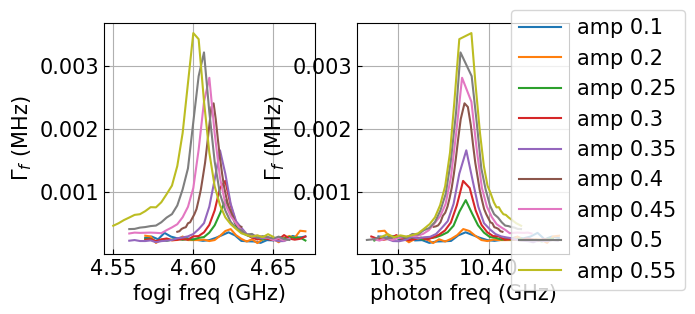

{'a0': 0, 'a2': 0.0018205087004203868, 'a4': 5.453415496958769e-13, 'a6': 3.75734998669941e-11, 'a8': 1.652011860642233e-13, 'a10': 3.3950620093037287e-12}


UnboundLocalError: local variable 'top' referenced before assignment

In [35]:
form = "antisech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 10.5

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(4.5, target_freq, duration, const=const, form=form, tr=True)